# 08 — Modelado, Validación Temporal y Explicabilidad (V11)

**LEE** `dataset_v11_fe.csv` (+ `selected_features_v11.json` si existe).
**Anterior**: `07_feature_selection.ipynb`

## Contenido (nivel TFM)
1. Comparación de modelos con **nested CV** (5×3) y métrica **coste-sensible** (`scorer_academico`).
2. Búsqueda de hiperparámetros de XGBoost.
3. **Validación temporal**: entrenar en cohortes viejas (≤2011) y predecir las nuevas (≥2018).
   Responde la pregunta central: ¿un modelo entrenado en el pasado generaliza al futuro?
4. **Explicabilidad con SHAP**: qué materias / bloques / demografía impulsan el riesgo.

`Ejercicio` se EXCLUYE de las features del modelo (sería una fuga del año); se usa solo
para construir el split temporal.

In [1]:
import sys, json, subprocess
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import (StratifiedKFold, cross_validate, train_test_split,
                                     RandomizedSearchCV, GridSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score
from xgboost import XGBClassifier
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.float_format','{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted'); plt.rcParams['figure.dpi']=110

_cwd=Path('.').resolve()
BASE_DIR=next((p for p in [_cwd,_cwd.parent,_cwd.parent.parent] if (p/'data').exists()), _cwd.parent)
sys.path.append(str(BASE_DIR)); sys.path.append(str(BASE_DIR/'notebooks'))
from src.utils.metrics import scorer_academico, score_academico, COST_MATRIX
from preprocessing_pipeline import build_preprocessor

try:
    import shap
except ImportError:
    subprocess.run([sys.executable,'-m','pip','install','shap','-q']); import shap

SEED=42; CAT_ORDER=['buen_alumno','en_riesgo','con_dificultades']
CV=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
CV_INNER=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

In [2]:
# Cargar dataset (preferir el de feature engineering; si no, el preprocesado)
P_FE=BASE_DIR/'data'/'dataset_v11_fe.csv'; P_PRE=BASE_DIR/'data'/'dataset_v11_preproc.csv'
P_IN=P_FE if P_FE.exists() else P_PRE
df=pd.read_csv(P_IN)
df['categoria_target']=pd.Categorical(df['categoria_target'],categories=CAT_ORDER,ordered=True)
print(f'Dataset: {P_IN.name}  {df.shape}')

# Features: numéricas + categóricas que codifica el pipeline; EXCLUIR target y Ejercicio
EXCL={'target_num','categoria_target','GuidAlumno'}
NIVS=[c for c in ['NivEstudio','NivCurso'] if c in df.columns]
feat_cols=[c for c in df.columns if c not in EXCL and c!='Ejercicio']
# DECISIÓN V11: usar el CONJUNTO COMPLETO de features (explicabilidad por materia/bloque).
# El subconjunto de 07 (VIF + perm.importance) se reporta como análisis de parsimonia,
# pero el modelo final NO se poda: XGBoost tolera la multicolinealidad y así SHAP puede
# mostrar el peso de las materias individuales y los bloques temáticos.
print(f'Modelo sobre conjunto COMPLETO: {len(feat_cols)} features (incluye materias y bloques)')
X=df[feat_cols].copy(); y=df['target_num'].values; ejercicio=df['Ejercicio'].values
print(f'X: {X.shape}  |  target: {dict(zip(*np.unique(y,return_counts=True)))}')

# PROTOCOLO ANTI-LEAKAGE: apartar un TEST held-out (20%) que NO se toca en la CV ni en la
# búsqueda de hiperparámetros. Todo el desarrollo (CV = validación + tuning) usa solo el 80%
# de desarrollo; el test se evalúa UNA sola vez al final → estimación honesta de generalización.
X_dev,X_test,y_dev,y_test,ej_dev,ej_test = train_test_split(
    X, y, ejercicio, test_size=0.20, stratify=y, random_state=SEED)
print(f'Desarrollo (CV + tuning): {len(y_dev)}  |  TEST held-out (intacto hasta el final): {len(y_test)}')

Dataset: dataset_v11_fe.csv  (1210, 70)
Modelo sobre conjunto COMPLETO: 67 features (incluye materias y bloques)
X: (1210, 67)  |  target: {np.int64(0): np.int64(869), np.int64(1): np.int64(216), np.int64(2): np.int64(125)}
Desarrollo (CV + tuning): 968  |  TEST held-out (intacto hasta el final): 242


In [3]:
# Wrapper XGBoost con balanceo de clases por sample_weight
class BalancedXGB(XGBClassifier):
    def fit(self, X, y, **kw):
        sw=compute_sample_weight('balanced', y)
        return super().fit(X, y, sample_weight=sw, **kw)

def make_pipe(clf):
    # Opción B: XGBoost maneja NaN nativamente → NO imputar ni escalar (preserva la
    # señal de ausencia: 'este nivel no cursa esa materia'). RandomForest (sklearn) y
    # LogisticRegression NO toleran NaN → se imputa y escala como siempre.
    es_xgb = isinstance(clf, XGBClassifier)
    return Pipeline([('prep', build_preprocessor(X.columns.tolist(),
                      group_col='NivEstudio', nivcurso_col='NivCurso',
                      scale=not es_xgb, impute=not es_xgb)),
                     ('clf', clf)])

# Modelos REGULARIZADOS para reducir sobreajuste (RF con hojas grandes y profundidad
# limitada; XGBoost con regularización fuerte L1/L2 + gamma + submuestreo bajo).
modelos={
 'Dummy (most_frequent)': DummyClassifier(strategy='most_frequent'),
 'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', C=0.5, random_state=SEED),
 'RandomForest': RandomForestClassifier(n_estimators=400, min_samples_leaf=15, max_depth=8,
                    max_features='sqrt', class_weight='balanced', random_state=SEED, n_jobs=-1),
 'XGBoost (balanced)': BalancedXGB(n_estimators=200, max_depth=2, learning_rate=0.05,
                    subsample=0.7, colsample_bytree=0.6, min_child_weight=10,
                    reg_lambda=10, reg_alpha=1, gamma=0.5, eval_metric='mlogloss',
                    random_state=SEED, n_jobs=-1, objective='multi:softprob', num_class=3),
}

In [4]:
# ── Decisión por coste esperado (alternativa al argmax de probabilidad) ──────
# best_pipe.predict(X) usa argmax: elige la clase MÁS PROBABLE, ignorando que los
# errores no cuestan lo mismo (ver COST_MATRIX). Predecir buen_alumno cuando es
# con_dificultades cuesta 5; al revés cuesta 2. Con esta regla, en vez de la clase
# más probable, se elige la que MINIMIZA EL COSTE ESPERADO dado el vector de
# probabilidades. Esto sesga las predicciones lejos de 'buen_alumno' cuando hay
# probabilidad real de en_riesgo/con_dificultades — ataca directamente el problema
# de "falsa tranquilidad" detectado en la validación temporal de ESO (§3b).
def predict_cost_sensitive(pipe, X):
    proba = pipe.predict_proba(X)        # proba[i, r] = P(clase real = r)
    expected_cost = proba @ COST_MATRIX  # expected_cost[i, c] = coste esperado de predecir c
    return expected_cost.argmin(axis=1)

## 1. Comparación de modelos — CV sobre DESARROLLO (coste-sensible: `score_academico`)

TRAIN vs TEST (CV 5-fold sobre DESARROLLO 80%) — métrica = score_academico (la brecha = sobreajuste):
               modelo  acad_train  acad_test  gap_acad  acc_train  acc_test  gap_acc
         RandomForest       0.945      0.938     0.007      0.802     0.780    0.022
   XGBoost (balanced)       0.958      0.938     0.021      0.846     0.789    0.057
   LogisticRegression       0.953      0.935     0.018      0.849     0.802    0.047
Dummy (most_frequent)       0.789      0.789    -0.000      0.718     0.718   -0.000

F1 macro y Recall macro (CV test) — exponen si el modelo detecta las clases minoritarias:
               modelo  f1_train  f1_test  recall_train  recall_test
         RandomForest     0.745    0.712         0.814        0.774
   XGBoost (balanced)     0.803    0.710         0.869        0.758
   LogisticRegression     0.790    0.704         0.844        0.748
Dummy (most_frequent)     0.279    0.279         0.333        0.333


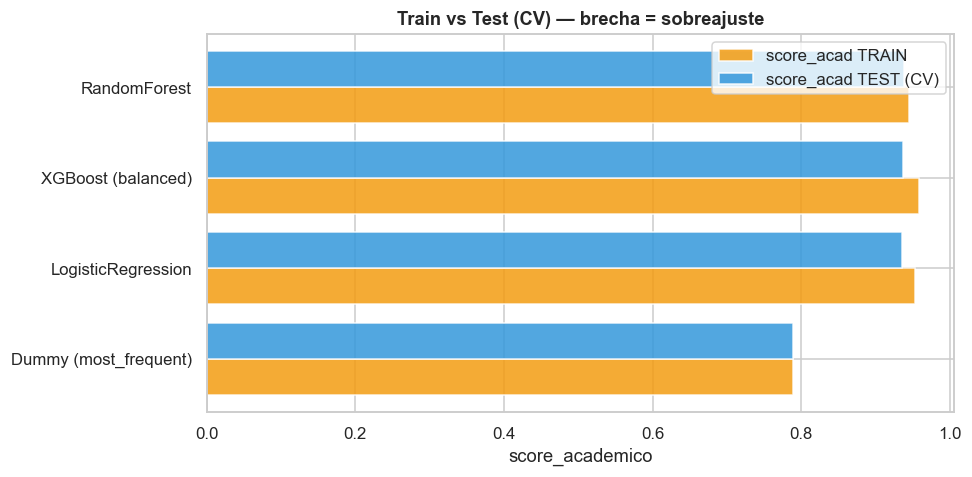


Brecha grande (train >> test) = sobreajuste.


In [5]:
# Métrica optimizada: score_academico (coste-sensible). Acompañamos con accuracy, F1 macro y recall macro.
scoring={'score_acad':scorer_academico,'accuracy':'accuracy',
         'f1_macro':'f1_macro','recall_macro':'recall_macro'}

filas=[]
for nombre,clf in modelos.items():
    cv=cross_validate(make_pipe(clf), X_dev, y_dev, cv=CV, scoring=scoring, n_jobs=-1, return_train_score=True)
    filas.append({'modelo':nombre,
        'acad_train':cv['train_score_acad'].mean(), 'acad_test':cv['test_score_acad'].mean(),
        'gap_acad':cv['train_score_acad'].mean()-cv['test_score_acad'].mean(),
        'acad_test_std':cv['test_score_acad'].std(),
        'acc_train':cv['train_accuracy'].mean(), 'acc_test':cv['test_accuracy'].mean(),
        'gap_acc':cv['train_accuracy'].mean()-cv['test_accuracy'].mean(),
        'f1_test':cv['test_f1_macro'].mean(), 'f1_train':cv['train_f1_macro'].mean(),
        'recall_test':cv['test_recall_macro'].mean(), 'recall_train':cv['train_recall_macro'].mean()})
res=pd.DataFrame(filas).sort_values('acad_test', ascending=False)
print('TRAIN vs TEST (CV 5-fold sobre DESARROLLO 80%) — métrica = score_academico (la brecha = sobreajuste):')
print(res[['modelo','acad_train','acad_test','gap_acad','acc_train','acc_test','gap_acc']].round(3).to_string(index=False))
print()
print('F1 macro y Recall macro (CV test) — exponen si el modelo detecta las clases minoritarias:')
print(res[['modelo','f1_train','f1_test','recall_train','recall_test']].round(3).to_string(index=False))

fig,ax=plt.subplots(figsize=(9,4.5))
yp=np.arange(len(res))
ax.barh(yp+0.2, res['acad_train'], height=0.4, color='#f39c12', alpha=.85, label='score_acad TRAIN')
ax.barh(yp-0.2, res['acad_test'],  height=0.4, color='#3498db', alpha=.85, label='score_acad TEST (CV)')
ax.set_yticks(yp); ax.set_yticklabels(res['modelo']); ax.invert_yaxis()
ax.set_xlabel('score_academico'); ax.set_title('Train vs Test (CV) — brecha = sobreajuste', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()
print('\nBrecha grande (train >> test) = sobreajuste.')

## 2. Búsqueda de hiperparámetros — XGBoost

In [6]:
# Espacio sesgado a REGULARIZACIÓN (árboles poco profundos, hojas con muchas
# observaciones, L1/L2 y gamma altos, submuestreo) → reduce la brecha train-test.
espacio={'clf__max_depth':[1,2,3],'clf__learning_rate':[0.02,0.05,0.08],
 'clf__n_estimators':[100,200,300],'clf__subsample':[0.6,0.7,0.8],
 'clf__colsample_bytree':[0.4,0.5,0.6],'clf__min_child_weight':[5,10,20],
 'clf__reg_lambda':[5,10,20,50],'clf__reg_alpha':[0,1,5],'clf__gamma':[0,0.5,1,2]}
base=BalancedXGB(eval_metric='mlogloss', random_state=SEED, n_jobs=-1,
                 objective='multi:softprob', num_class=3)
rs=RandomizedSearchCV(make_pipe(base), {**espacio}, n_iter=30, cv=CV_INNER,
     scoring=scorer_academico, random_state=SEED, n_jobs=-1, verbose=0)
rs.fit(X_dev,y_dev)   # tuning SOLO sobre desarrollo; el test held-out queda intacto
print(f'Mejor score_acad (CV interna sobre desarrollo): {rs.best_score_:.4f}')
print('Mejores hiperparámetros:')
for k,v in rs.best_params_.items(): print(f'  {k.replace("clf__","")}: {v}')
best_pipe=rs.best_estimator_

Mejor score_acad (CV interna sobre desarrollo): 0.9382
Mejores hiperparámetros:
  subsample: 0.8
  reg_lambda: 5
  reg_alpha: 0
  n_estimators: 100
  min_child_weight: 5
  max_depth: 2
  learning_rate: 0.08
  gamma: 0.5
  colsample_bytree: 0.5


## 2b. Evaluación FINAL en el TEST held-out (estimación honesta)

El 20% apartado al inicio **no participó** en la CV ni en la búsqueda de hiperparámetros.
Esta es la estimación insesgada de cómo generaliza el modelo elegido a datos no vistos.

XGBoost regularizado — DESARROLLO (in-sample) vs TEST held-out (nunca tocado):
  score_acad: dev 0.956 | TEST 0.926
  accuracy  : dev 0.843 | TEST 0.785

score_academico TEST — argmax: 0.926 | coste esperado: 0.931
accuracy        TEST — argmax: 0.785 | coste esperado: 0.731

Informe por clase (TEST held-out) — argmax (decisión estándar):
                  precision    recall  f1-score   support

     buen_alumno       0.94      0.83      0.88       174
       en_riesgo       0.51      0.65      0.57        43
con_dificultades       0.55      0.72      0.62        25

        accuracy                           0.79       242
       macro avg       0.66      0.73      0.69       242
    weighted avg       0.82      0.79      0.80       242

Informe por clase (TEST held-out) — decisión por COSTE ESPERADO:
                  precision    recall  f1-score   support

     buen_alumno       0.98      0.71      0.83       174
       en_riesgo       0.42      0.79      0.55        43
con_dificu

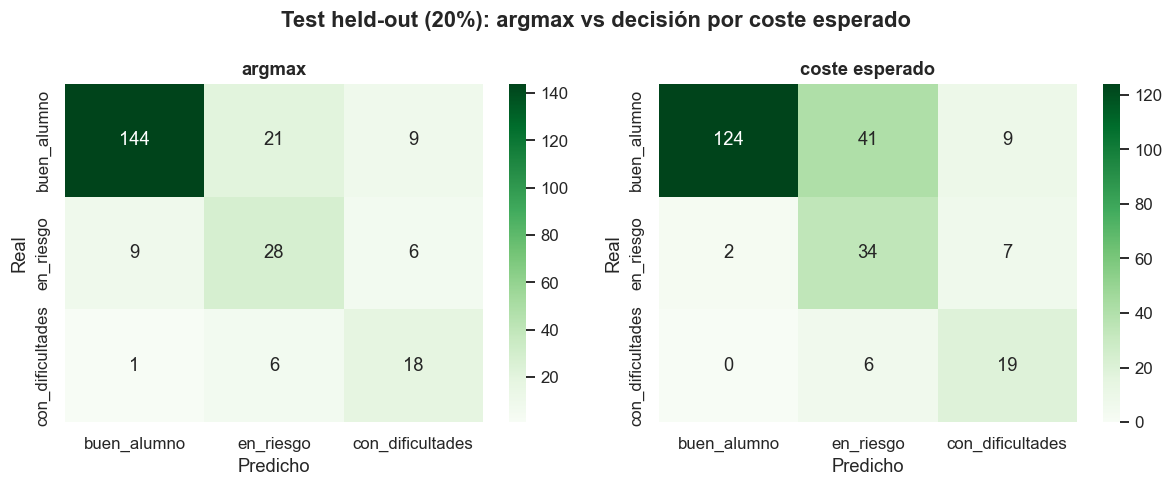

In [7]:
# best_pipe ya viene reajustado en X_dev por RandomizedSearchCV (refit=True). Evaluamos en TEST.
print('XGBoost regularizado — DESARROLLO (in-sample) vs TEST held-out (nunca tocado):')
print(f'  score_acad: dev {scorer_academico(best_pipe,X_dev,y_dev):.3f} | TEST {scorer_academico(best_pipe,X_test,y_test):.3f}')
print(f'  accuracy  : dev {accuracy_score(y_dev,best_pipe.predict(X_dev)):.3f} | TEST {accuracy_score(y_test,best_pipe.predict(X_test)):.3f}')

pred_argmax = best_pipe.predict(X_test)
pred_cs     = predict_cost_sensitive(best_pipe, X_test)

print()
print(f'score_academico TEST — argmax: {score_academico(y_test,pred_argmax):.3f} | coste esperado: {score_academico(y_test,pred_cs):.3f}')
print(f'accuracy        TEST — argmax: {accuracy_score(y_test,pred_argmax):.3f} | coste esperado: {accuracy_score(y_test,pred_cs):.3f}')
print()
print('Informe por clase (TEST held-out) — argmax (decisión estándar):')
print(classification_report(y_test, pred_argmax, target_names=CAT_ORDER))
print('Informe por clase (TEST held-out) — decisión por COSTE ESPERADO:')
print(classification_report(y_test, pred_cs, target_names=CAT_ORDER))

fig,axes=plt.subplots(1,2,figsize=(11,4.5))
for ax,pred,titulo in zip(axes,[pred_argmax,pred_cs],['argmax','coste esperado']):
    cmx=confusion_matrix(y_test,pred)
    sns.heatmap(cmx,annot=True,fmt='d',cmap='Greens',xticklabels=CAT_ORDER,yticklabels=CAT_ORDER,ax=ax)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title(titulo, fontweight='bold')
plt.suptitle('Test held-out (20%): argmax vs decisión por coste esperado', fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Validación temporal — train pasado (≤2011), test futuro (≥2018)

La pregunta central del TFM: un modelo entrenado con cohortes históricas, ¿predice cohortes
futuras? Es una prueba mucho más exigente (y realista) que el CV aleatorio.

Train (<=2011): 883  |  Test (>=2018): 322
VALIDACIÓN TEMPORAL — TRAIN (≤2011) vs TEST (≥2018):
  TRAIN: score_acad 0.971 | accuracy 0.887
  TEST : score_acad 0.786 | accuracy 0.568  (argmax)
  TEST : score_acad 0.818 | accuracy 0.559  (coste esperado)
  BRECHA train-test (score_acad, argmax): 0.185

Informe por clase — TEST temporal (>=2018) — argmax:
                  precision    recall  f1-score   support

     buen_alumno       0.61      0.84      0.71       146
       en_riesgo       0.52      0.33      0.40       123
con_dificultades       0.44      0.38      0.41        53

        accuracy                           0.57       322
       macro avg       0.53      0.52      0.51       322
    weighted avg       0.55      0.57      0.54       322

Informe por clase — TEST temporal (>=2018) — decisión por COSTE ESPERADO:
                  precision    recall  f1-score   support

     buen_alumno       0.66      0.70      0.68       146
       en_riesgo       0.50      0.42      0.

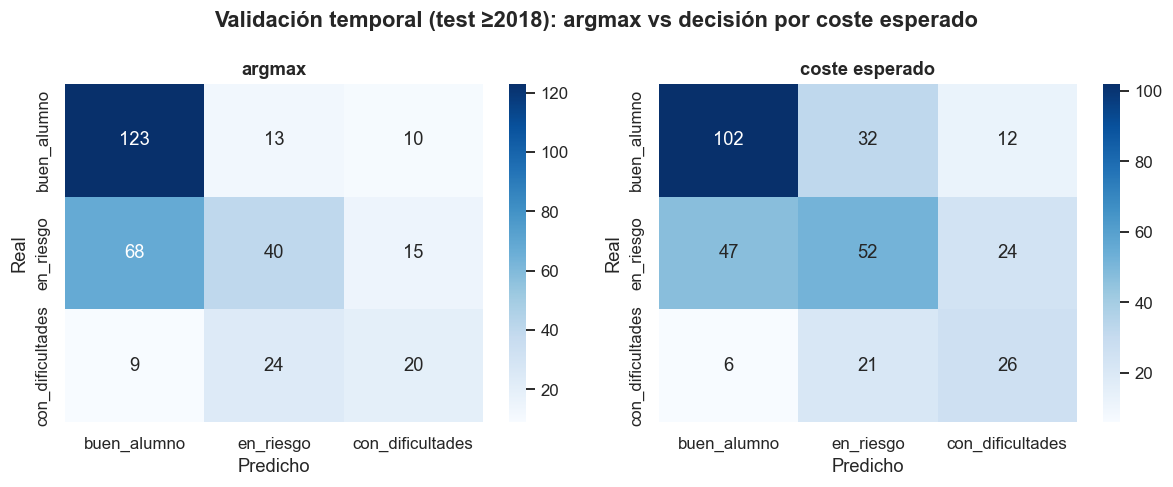

In [8]:
mask_tr=ejercicio<=2011; mask_te=ejercicio>=2018
Xtr,Xte=X[mask_tr],X[mask_te]; ytr,yte=y[mask_tr],y[mask_te]
print(f'Train (<=2011): {mask_tr.sum()}  |  Test (>=2018): {mask_te.sum()}')

# Modelo temporal: mismos hiperparámetros del mejor XGB
temp_pipe=make_pipe(BalancedXGB(**{k.replace('clf__',''):v for k,v in rs.best_params_.items()},
                    eval_metric='mlogloss', random_state=SEED, n_jobs=-1,
                    objective='multi:softprob', num_class=3))
temp_pipe.fit(Xtr,ytr)
pred_tr=temp_pipe.predict(Xtr)
pred_te=temp_pipe.predict(Xte)
pred_te_cs=predict_cost_sensitive(temp_pipe, Xte)

# Comparación TRAIN (in-sample, <=2011) vs TEST (out-of-sample temporal, >=2018)
acad_tr=scorer_academico(temp_pipe,Xtr,ytr); acad_te=scorer_academico(temp_pipe,Xte,yte)
print('VALIDACIÓN TEMPORAL — TRAIN (≤2011) vs TEST (≥2018):')
print(f'  TRAIN: score_acad {acad_tr:.3f} | accuracy {accuracy_score(ytr,pred_tr):.3f}')
print(f'  TEST : score_acad {acad_te:.3f} | accuracy {accuracy_score(yte,pred_te):.3f}  (argmax)')
print(f'  TEST : score_acad {score_academico(yte,pred_te_cs):.3f} | accuracy {accuracy_score(yte,pred_te_cs):.3f}  (coste esperado)')
print(f'  BRECHA train-test (score_acad, argmax): {acad_tr-acad_te:.3f}')
print()
print('Informe por clase — TEST temporal (>=2018) — argmax:')
print(classification_report(yte, pred_te, target_names=CAT_ORDER))
print('Informe por clase — TEST temporal (>=2018) — decisión por COSTE ESPERADO:')
print(classification_report(yte, pred_te_cs, target_names=CAT_ORDER))
# Desglose del test temporal POR NIVEL → ¿la caída es por cambio de composición de nivel?
te_niv=pd.DataFrame({'nivel':df.loc[mask_te,'NivEstudio'].values,'y':yte,'pred':pred_te})
print('Accuracy del test temporal POR NIVEL (argmax, diagnóstico tiempo vs nivel):')
for niv,g in te_niv.groupby('nivel'):
    print(f'  {niv:<14} n={len(g):>4}  accuracy {accuracy_score(g.y,g.pred):.3f}')
print('Composición de nivel:')
print('  TRAIN (<=2011):', pd.Series(df.loc[mask_tr,'NivEstudio'].values).value_counts().to_dict())
print('  TEST  (>=2018):', pd.Series(df.loc[mask_te,'NivEstudio'].values).value_counts().to_dict())

fig,axes=plt.subplots(1,2,figsize=(11,4.5))
for ax,pred,titulo in zip(axes,[pred_te,pred_te_cs],['argmax','coste esperado']):
    cmx=confusion_matrix(yte,pred)
    sns.heatmap(cmx,annot=True,fmt='d',cmap='Blues',xticklabels=CAT_ORDER,yticklabels=CAT_ORDER,ax=ax)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title(titulo, fontweight='bold')
plt.suptitle('Validación temporal (test ≥2018): argmax vs decisión por coste esperado', fontweight='bold')
plt.tight_layout(); plt.show()

### 3b. ¿Por qué falla la transferencia temporal en ESO?

El desglose por nivel mostró que la caída se concentra en ESO (Primaria y Bachillerato
transfieren bien). Investigamos si es **deriva real** del cohorte —el ESO de 2019 tiene
distinta proporción de riesgo o distinto nivel de notas que el de 2010— o si ESO es
simplemente más difícil de predecir.

In [9]:
# (a) Confusión SOLO del ESO en el test temporal: ¿en qué se equivoca?
eso_te=(df.loc[mask_te,'NivEstudio'].values=='ESO')
print('ESO en test temporal (>=2018): n =', int(eso_te.sum()))
print('Matriz de confusión ESO — argmax (filas=real, columnas=predicho):')
print(pd.DataFrame(confusion_matrix(yte[eso_te], pred_te[eso_te], labels=[0,1,2]),
      index=[f'real_{c}' for c in CAT_ORDER], columns=[f'pred_{c}' for c in CAT_ORDER]).to_string())
print()
print('Informe por clase — SOLO ESO, argmax:')
print(classification_report(yte[eso_te], pred_te[eso_te], target_names=CAT_ORDER, zero_division=0))

print('Matriz de confusión ESO — decisión por COSTE ESPERADO:')
print(pd.DataFrame(confusion_matrix(yte[eso_te], pred_te_cs[eso_te], labels=[0,1,2]),
      index=[f'real_{c}' for c in CAT_ORDER], columns=[f'pred_{c}' for c in CAT_ORDER]).to_string())
print()
print('Informe por clase — SOLO ESO, decisión por COSTE ESPERADO:')
print(classification_report(yte[eso_te], pred_te_cs[eso_te], target_names=CAT_ORDER, zero_division=0))

# (b) Comparar el cohorte ESO de 2010 (train) vs 2019 (test): clases + nivel de notas 1EV
print('Comparación del cohorte ESO — 2010 (train) vs 2019 (test):')
for anio in [2010, 2019]:
    sub=df[(df['Ejercicio']==anio)&(df['NivEstudio']=='ESO')]
    if len(sub)==0: continue
    dist=sub['categoria_target'].value_counts(normalize=True).reindex(CAT_ORDER).round(3).to_dict()
    nm=sub['nota_media_1ev'].mean() if 'nota_media_1ev' in sub.columns else float('nan')
    print(f'  {anio} ESO (n={len(sub):>3}): clases={dist} | nota_media_1ev={nm:.2f}')

ESO en test temporal (>=2018): n = 134
Matriz de confusión ESO — argmax (filas=real, columnas=predicho):
                       pred_buen_alumno  pred_en_riesgo  pred_con_dificultades
real_buen_alumno                     13               4                      5
real_en_riesgo                       33              28                      7
real_con_dificultades                 4              20                     20

Informe por clase — SOLO ESO, argmax:
                  precision    recall  f1-score   support

     buen_alumno       0.26      0.59      0.36        22
       en_riesgo       0.54      0.41      0.47        68
con_dificultades       0.62      0.45      0.53        44

        accuracy                           0.46       134
       macro avg       0.47      0.49      0.45       134
    weighted avg       0.52      0.46      0.47       134

Matriz de confusión ESO — decisión por COSTE ESPERADO:
                       pred_buen_alumno  pred_en_riesgo  pred_con_dificultad

### 3c. Validación temporal de origen móvil (rolling-origin)

La validación de §3 usa **un único corte** (train≤2011, test≥2018). Es una sola observación:
no permite distinguir un patrón sistemático de un accidente de ese corte concreto. Aquí se
repite el experimento con **varios cortes de ventana expansiva** — se va incorporando más
años al entrenamiento y se testea siempre con el bloque de años siguiente — para comprobar
si la caída de rendimiento observada en §3 es consistente o fue idiosincrática de ese corte.

**Nota de tamaño muestral**: el primer corte tiene un test de solo 22 alumnos (2016+2018) —
interpretar con la misma cautela que el resto de subgrupos pequeños de este notebook.

=== 2010-11 -> 2016+18 (train n=883, test n=22) ===
  score_acad: train 0.971 | test 0.882  (gap 0.089)
  accuracy test: 0.682  |  F1 macro test argmax: 0.468  |  F1 macro test coste esperado: 0.387

=== 2010-18 -> 2019 (train n=905, test n=234) ===
  score_acad: train 0.970 | test 0.755  (gap 0.216)
  accuracy test: 0.509  |  F1 macro test argmax: 0.497  |  F1 macro test coste esperado: 0.536

=== 2010-19 -> 2020 (train n=1139, test n=71) ===
  score_acad: train 0.958 | test 0.845  (gap 0.113)
  accuracy test: 0.732  |  F1 macro test argmax: 0.282  |  F1 macro test coste esperado: 0.369

=== RESUMEN — Validación de origen móvil (todos los cortes) ===
             split  n_train  n_test  acad_train  acad_test  gap_acad  acc_test  f1_test_argmax  f1_test_coste
2010-11 -> 2016+18      883      22       0.971      0.882     0.089     0.682           0.468          0.387
   2010-18 -> 2019      905     234       0.970      0.755     0.216     0.509           0.497          0.536
   2010-19

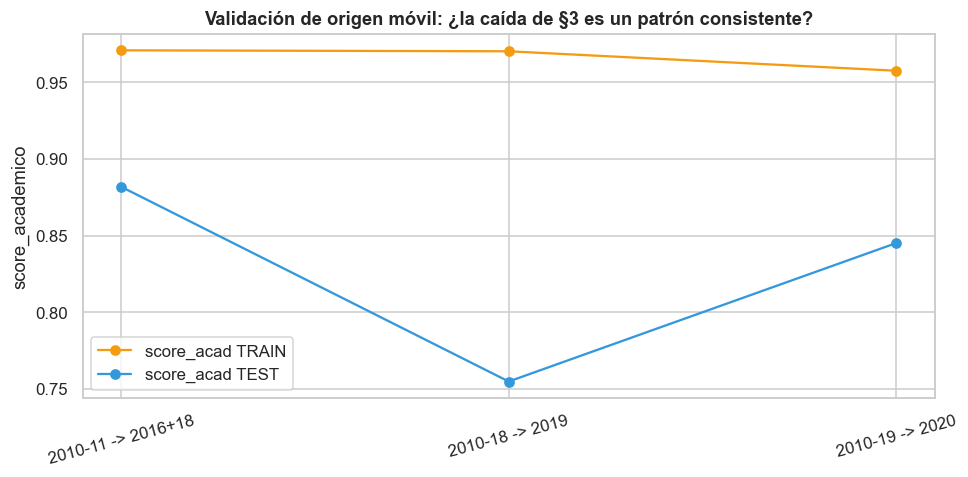


Si TEST cae de forma consistente en los 3 cortes, confirma que la degradación temporal
es un patrón sistemático y no un accidente del corte único de §3.


In [10]:
cortes = [
    {'train': [2010, 2011],                     'test': [2016, 2018], 'label': '2010-11 -> 2016+18'},
    {'train': [2010, 2011, 2016, 2018],          'test': [2019],       'label': '2010-18 -> 2019'},
    {'train': [2010, 2011, 2016, 2018, 2019],    'test': [2020],       'label': '2010-19 -> 2020'},
]

resultados_rolling = []
for corte in cortes:
    m_tr = pd.Series(ejercicio).isin(corte['train']).values
    m_te = pd.Series(ejercicio).isin(corte['test']).values
    n_tr, n_te = int(m_tr.sum()), int(m_te.sum())
    if n_tr < 30 or n_te < 10:
        print(f"{corte['label']}: omitido (n_train={n_tr}, n_test={n_te} insuficiente)")
        continue

    Xtr_r, Xte_r = X[m_tr], X[m_te]
    ytr_r, yte_r = y[m_tr], y[m_te]

    pipe_r = make_pipe(BalancedXGB(**{k.replace('clf__',''):v for k,v in rs.best_params_.items()},
                        eval_metric='mlogloss', random_state=SEED, n_jobs=-1,
                        objective='multi:softprob', num_class=3))
    pipe_r.fit(Xtr_r, ytr_r)
    pred_r    = pipe_r.predict(Xte_r)
    pred_r_cs = predict_cost_sensitive(pipe_r, Xte_r)

    acad_tr_r = scorer_academico(pipe_r, Xtr_r, ytr_r)
    acad_te_r = scorer_academico(pipe_r, Xte_r, yte_r)
    f1_r      = f1_score(yte_r, pred_r,    average='macro')
    f1_r_cs   = f1_score(yte_r, pred_r_cs, average='macro')

    resultados_rolling.append({
        'split': corte['label'], 'n_train': n_tr, 'n_test': n_te,
        'acad_train': acad_tr_r, 'acad_test': acad_te_r,
        'gap_acad': acad_tr_r - acad_te_r,
        'acc_test': accuracy_score(yte_r, pred_r),
        'f1_test_argmax': f1_r, 'f1_test_coste': f1_r_cs,
    })
    print(f"=== {corte['label']} (train n={n_tr}, test n={n_te}) ===")
    print(f"  score_acad: train {acad_tr_r:.3f} | test {acad_te_r:.3f}  (gap {acad_tr_r-acad_te_r:.3f})")
    print(f"  accuracy test: {accuracy_score(yte_r, pred_r):.3f}  |  "
          f"F1 macro test argmax: {f1_r:.3f}  |  F1 macro test coste esperado: {f1_r_cs:.3f}")
    print()

res_rolling = pd.DataFrame(resultados_rolling)
print('=== RESUMEN — Validación de origen móvil (todos los cortes) ===')
print(res_rolling.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
xpos = np.arange(len(res_rolling))
ax.plot(xpos, res_rolling['acad_train'], 'o-', color='#f39c12', label='score_acad TRAIN')
ax.plot(xpos, res_rolling['acad_test'],  'o-', color='#3498db', label='score_acad TEST')
ax.set_xticks(xpos); ax.set_xticklabels(res_rolling['split'], rotation=15)
ax.set_ylabel('score_academico')
ax.set_title('Validación de origen móvil: ¿la caída de §3 es un patrón consistente?', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()
print('\nSi TEST cae de forma consistente en los 3 cortes, confirma que la degradación temporal')
print('es un patrón sistemático y no un accidente del corte único de §3.')

## 4. Explicabilidad con SHAP

Sobre el mejor XGBoost (ajustado en el conjunto de desarrollo). SHAP descompone cada predicción en la contribución de cada feature → qué materia/área/demografía dispara el riesgo.

Top 20 features (SHAP (media |valor SHAP|)):
n_suspensos_1ev             0.225
pct_asignaturas__SOC        0.182
pct_aprobado_1ev            0.163
nota_min_1ev                0.111
mat__Lengua_Castellana      0.106
fe_dispersion_comp          0.096
mat__Tecnologia             0.092
nota_min__STEM              0.087
mat__Ciencias               0.085
nota_min__SOC               0.067
nota_media__SOC             0.065
niv_eso                     0.064
edad_relativa               0.061
nota_media_1ev              0.056
nota_media__STEM            0.052
fe_riesgo_intenso           0.050
no_justificadas_1ev_log     0.047
mes_nacimiento              0.044
total_incidencias_1ev_log   0.044
NivCurso_freq               0.042


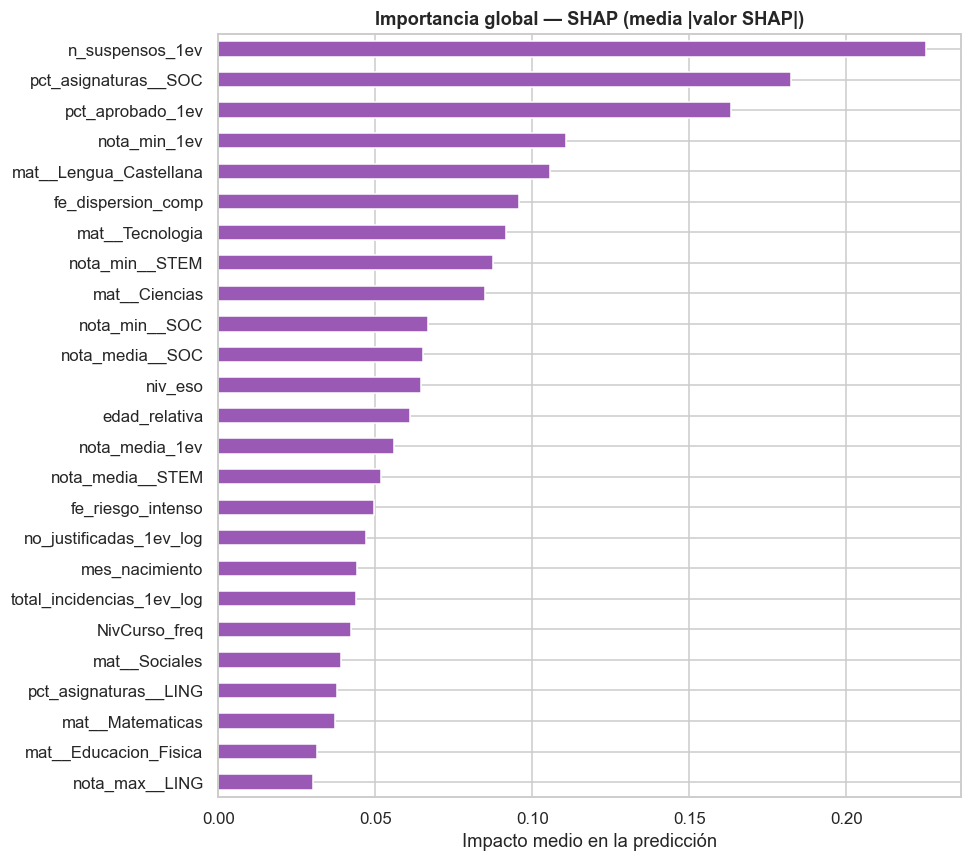

In [11]:
best_pipe.fit(X_dev,y_dev)
prep=best_pipe.named_steps['prep']; clf=best_pipe.named_steps['clf']
Xt=prep.transform(X_dev)
if not isinstance(Xt,pd.DataFrame):
    Xt=pd.DataFrame(np.asarray(Xt), columns=[f'f{i}' for i in range(np.asarray(Xt).shape[1])])
nf=Xt.shape[1]
explainer=shap.TreeExplainer(clf)
sv=explainer.shap_values(Xt)

def shap_global(sv, nf):
    # Devuelve importancia global (longitud = nº features), robusta a list/2D/3D
    if isinstance(sv, list):
        return np.mean([np.abs(np.asarray(s)).mean(0) for s in sv], axis=0)
    a=np.abs(np.asarray(sv))
    if a.ndim==2: return a.mean(0)
    feat_ax=next((ax for ax in range(a.ndim) if a.shape[ax]==nf), a.ndim-1)
    otros=tuple(ax for ax in range(a.ndim) if ax!=feat_ax)
    return a.mean(axis=otros)

try:
    glob=shap_global(sv, nf)
    imp=pd.Series(glob, index=Xt.columns).sort_values(ascending=False)
    fuente='SHAP (media |valor SHAP|)'
except Exception as e:
    print('SHAP global fallo, uso feature_importances_:', e)
    imp=pd.Series(clf.feature_importances_, index=Xt.columns).sort_values(ascending=False)
    fuente='XGBoost feature_importances_'
print(f'Top 20 features ({fuente}):'); print(imp.head(20).to_string())
fig,ax=plt.subplots(figsize=(9,8))
imp.head(25).iloc[::-1].plot(kind='barh', color='#9b59b6', ax=ax)
ax.set_title(f'Importancia global — {fuente}', fontweight='bold')
ax.set_xlabel('Impacto medio en la predicción'); plt.tight_layout(); plt.show()

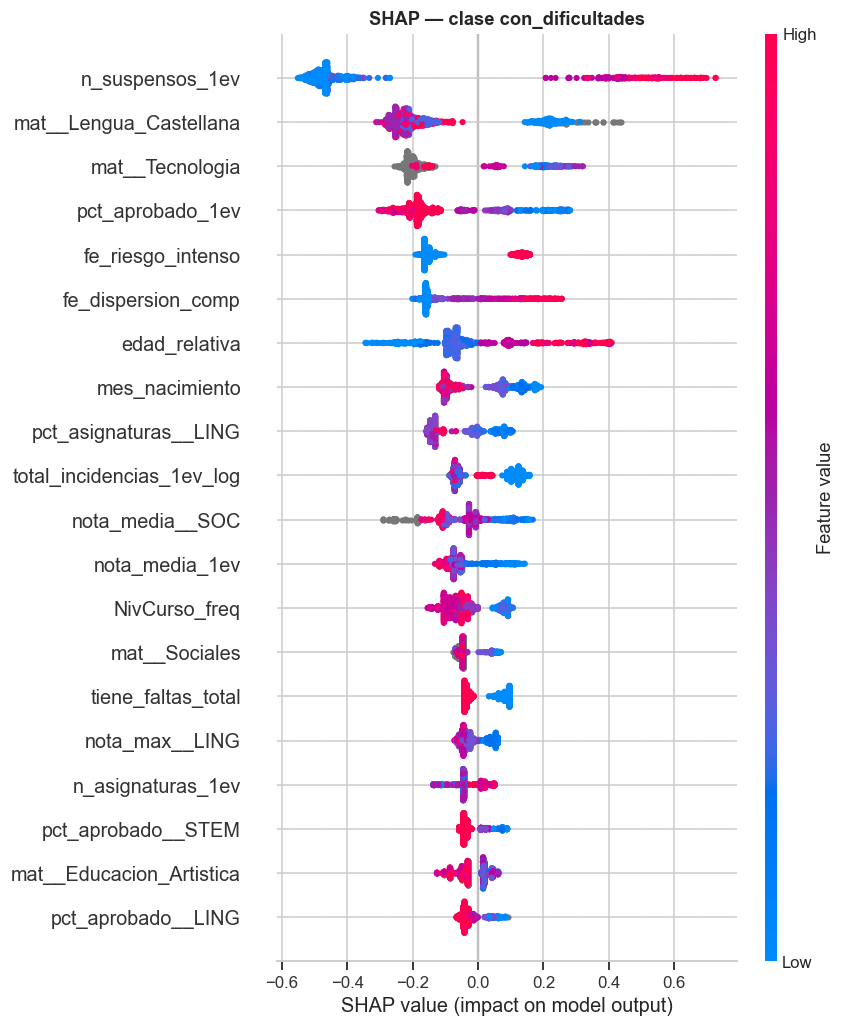

In [12]:
# SHAP summary plot (clase con_dificultades = la de mayor coste pedagógico)
try:
    idx_dif=CAT_ORDER.index('con_dificultades')
    if isinstance(sv,list):
        sv_dif=np.asarray(sv[idx_dif])
    else:
        a=np.asarray(sv)
        if a.ndim==3:
            if a.shape[-1]==len(CAT_ORDER): sv_dif=a[:,:,idx_dif]
            elif a.shape[0]==len(CAT_ORDER): sv_dif=a[idx_dif]
            else: sv_dif=a.take(idx_dif, axis=-1)
        else: sv_dif=a
    shap.summary_plot(sv_dif, Xt, show=False, max_display=20)
    plt.title('SHAP — clase con_dificultades', fontweight='bold'); plt.tight_layout(); plt.show()
except Exception as e:
    print('summary_plot omitido:', e)

## 5. Conclusiones

- **Mejor modelo**: XGBoost balanceado con búsqueda de hiperparámetros (ver §1-2).
- **Validación temporal (§3)**: cuantifica la generalización a cohortes futuras — la métrica
  honesta para un sistema de alerta temprana real.
- **Explicabilidad (§4)**: SHAP identifica las materias/áreas/variables demográficas que más
  pesan en el riesgo, base para la interpretación pedagógica de la memoria.